## Lab 1

### 1. Library Imports

In [1]:
# tensorflow must be imported before pandas/sklearn, otherwise the MKL that they
# load first breaks TF's GPU variable allocation and the kernel segfaults
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1786362987.427360  186604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786362987.464413  186604 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 2. Task 1: Environment Check

In [2]:
print("TensorFlow", tf.__version__)
print("Keras", tf.keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0
Keras 3.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Chapter 10 builds its Fashion MNIST model with `input_shape=` on the first layer, which is
deprecated. An `InputLayer` is used instead here.

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train, y_train = X_train_full[:-5000] / 255., y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:] / 255., y_train_full[-5000:]
X_test = X_test / 255.

print(X_train.shape, X_valid.shape, X_test.shape)

(55000, 28, 28) (5000, 28, 28) (10000, 28, 28)


In [4]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(shape=[28, 28]))  # replaces input_shape=[28, 28]
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()

I0000 00:00:1786362990.011623  186604 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1786362991.099044  186695 service.cc:153] XLA service 0x7ebaa402ec70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786362991.099064  186695 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)
I0000 00:00:1786362991.105341  186695 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786362991.137413  186695 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1786362991.140550  186695 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_556__.13


I0000 00:00:1786362992.887567  186695 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


I0000 00:00:1786362996.513189  186696 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_556__.13


I0000 00:00:1786362996.942682  186963 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 20 bytes spill stores, 20 bytes spill loads



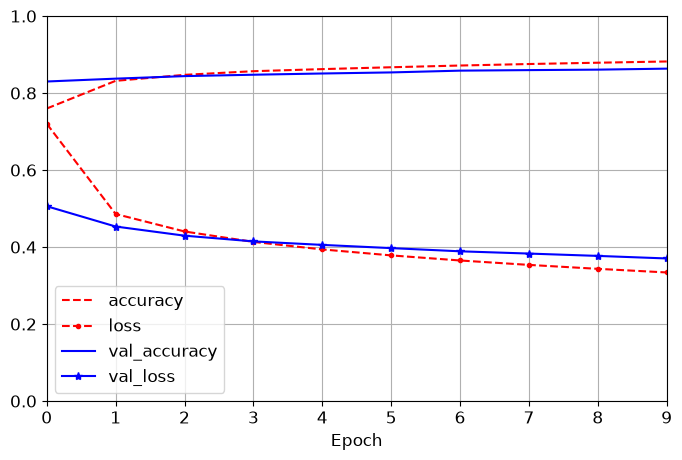

test accuracy: 0.8575000166893005


In [5]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid), verbose=0)

pd.DataFrame(history.history).plot(figsize=(8, 5), xlim=[0, 9], ylim=[0, 1], grid=True,
                                   xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.show()

print("test accuracy:", model.evaluate(X_test, y_test, verbose=0)[1])

### 3. Task 2: Loading the circle Dataset

In [6]:
def load_data(filename):
    with open(filename, "rb") as f:
        xtrain = np.load(f)
        ytrain = np.load(f)
        xval = np.load(f)
        yval = np.load(f)
    return xtrain, ytrain, xval, yval

X_train, y_train, X_val, y_val = load_data("circle.npy")

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(750, 2) (750,) (250, 2) (250,)


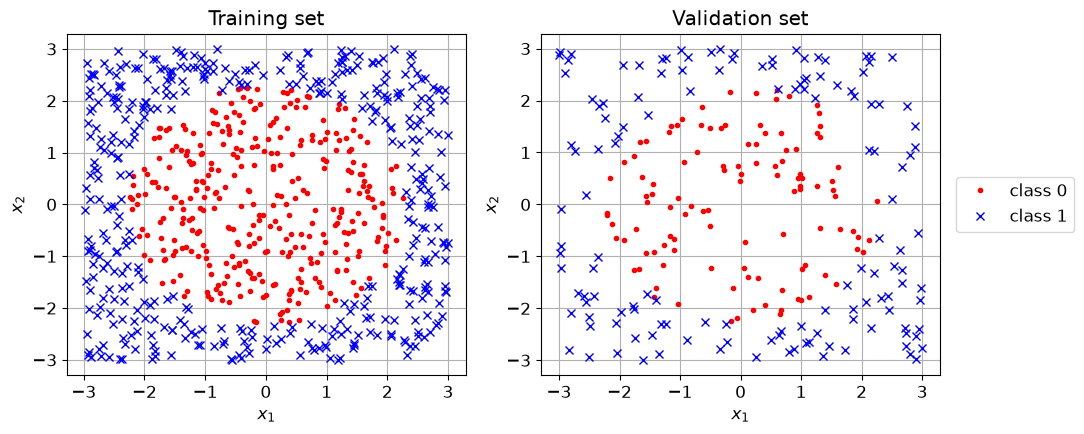

In [7]:
def plot_classes(X, y, ax, title):
    ax.plot(X[y == 0, 0], X[y == 0, 1], "r.", label="class 0")
    ax.plot(X[y == 1, 0], X[y == 1, 1], "bx", label="class 1")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.grid(True)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_classes(X_train, y_train, axes[0], "Training set")
plot_classes(X_val, y_val, axes[1], "Validation set")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

The prediction plots below shade the region each model assigns to class 1, with the true
labels drawn on top.

In [8]:
def plot_predictions(predict_fn, X, y, ax, title):
    x1s = np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 200)
    x2s = np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 200)
    x1, x2 = np.meshgrid(x1s, x2s)
    y_pred = predict_fn(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)
    ax.contourf(x1, x2, y_pred, levels=[0, 0.5, 1], colors=["mistyrose", "lightsteelblue"])
    plot_classes(X, y, ax, title)


def keras_predict(model):
    return lambda X: model.predict(X, verbose=0).ravel()

### 4. Task 2: MLP with One Hidden Layer

In [9]:
tf.random.set_seed(42)

model1 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[2]),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# the default SGD learning rate (0.01) leaves both models undertrained after
# 100 epochs, so it is set explicitly here
model1.compile(loss="binary_crossentropy",
               optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
               metrics=["accuracy"])
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1786363029.447227  186697 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77979__.8


I0000 00:00:1786363029.796723  186697 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77979__.8


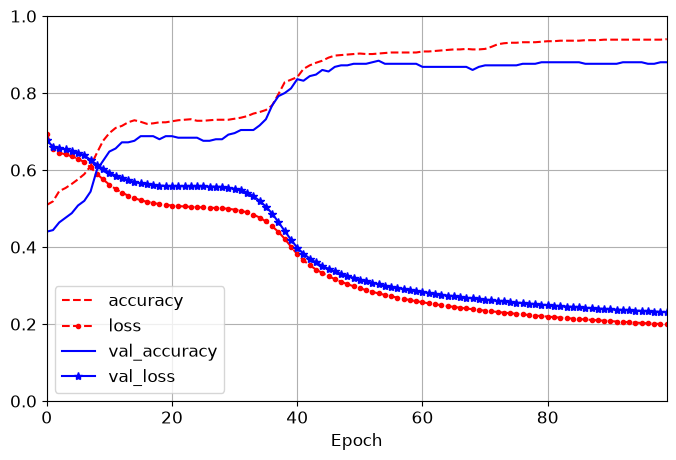

In [10]:
history1 = model1.fit(X_train, y_train, epochs=100,
                      validation_data=(X_val, y_val), verbose=0)

pd.DataFrame(history1.history).plot(figsize=(8, 5), xlim=[0, 99], ylim=[0, 1], grid=True,
                                    xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.show()

### 5. Task 2: MLP with Two Hidden Layers

In [11]:
tf.random.set_seed(42)

model2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[2]),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model2.compile(loss="binary_crossentropy",
               optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
               metrics=["accuracy"])
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1786363039.895878  186694 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94042__.9


I0000 00:00:1786363040.596178  186695 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94042__.9


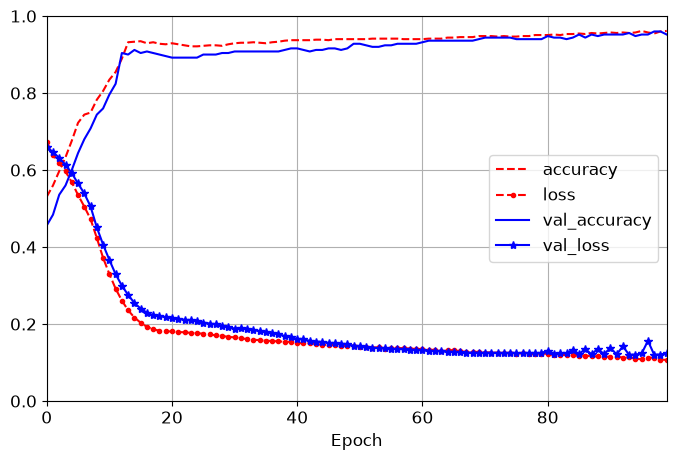

In [12]:
history2 = model2.fit(X_train, y_train, epochs=100,
                      validation_data=(X_val, y_val), verbose=0)

pd.DataFrame(history2.history).plot(figsize=(8, 5), xlim=[0, 99], ylim=[0, 1], grid=True,
                                    xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"])
plt.show()

### 6. Task 2: Comparison

In [13]:
rows = []
for name, model in [("1 hidden layer", model1), ("2 hidden layers", model2)]:
    rows.append({
        "model": name,
        "trainable params": model.count_params(),
        "train accuracy": model.evaluate(X_train, y_train, verbose=0)[1],
        "validation accuracy": model.evaluate(X_val, y_val, verbose=0)[1],
    })

pd.DataFrame(rows).set_index("model").round(4)

,trainable params,train accuracy,validation accuracy
model,,,
1 hidden layer,21,0.9387,0.880
2 hidden layers,51,0.9667,0.952


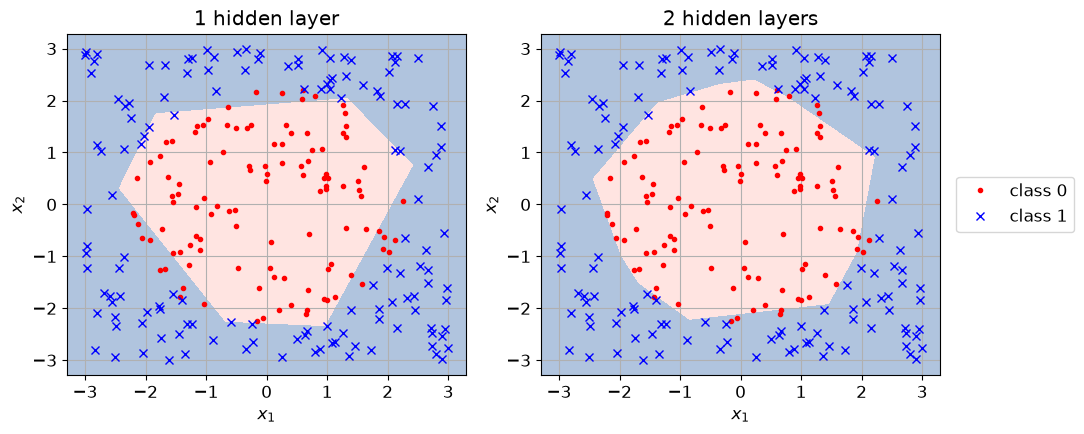

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_predictions(keras_predict(model1), X_val, y_val, axes[0], "1 hidden layer")
plot_predictions(keras_predict(model2), X_val, y_val, axes[1], "2 hidden layers")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

Both models were trained with the same optimiser and for the same 100 epochs. The two
hidden layer MLP reaches 95.2% validation accuracy against 88.0% for the single hidden
layer, using 51 trainable parameters instead of 21.

The prediction plots show why. Five ReLU units in one hidden layer can only cut the plane
with a handful of straight lines, so the class 1 region comes out as a polygon whose
corners slice into the circle. The second hidden layer lets the network recombine those
pieces, and the boundary ends up much closer to an actual circle.

So one hidden layer is not really sufficient here. It gets most of the points right
because the circle is large and well separated, but it cannot represent a curved boundary,
and the errors it does make sit in a predictable ring around the corners of the polygon.
Two hidden layers fit this dataset properly.

### 7. Task 3: The moons Dataset

In [15]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(np.bincount(y))

(800, 2) (200, 2)
[500 500]


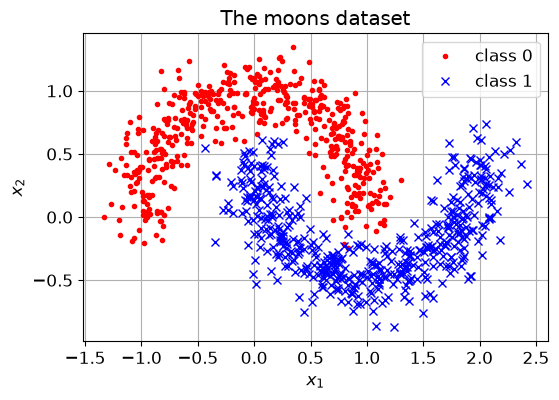

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_classes(X, y, ax, "The moons dataset")
ax.legend()
plt.show()

In [17]:
def plot_train_test(predict_fn, name):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_predictions(predict_fn, X_train, y_train, axes[0], f"{name} - training set")
    plot_predictions(predict_fn, X_test, y_test, axes[1], f"{name} - test set")
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()

### 8. Task 3: Perceptron

In [18]:
from sklearn.linear_model import Perceptron

per_clf = Perceptron(max_iter=1000, random_state=42)
per_clf.fit(X_train, y_train)

print("train accuracy:", per_clf.score(X_train, y_train))
print("test accuracy: ", per_clf.score(X_test, y_test))

train accuracy: 0.87125
test accuracy:  0.87


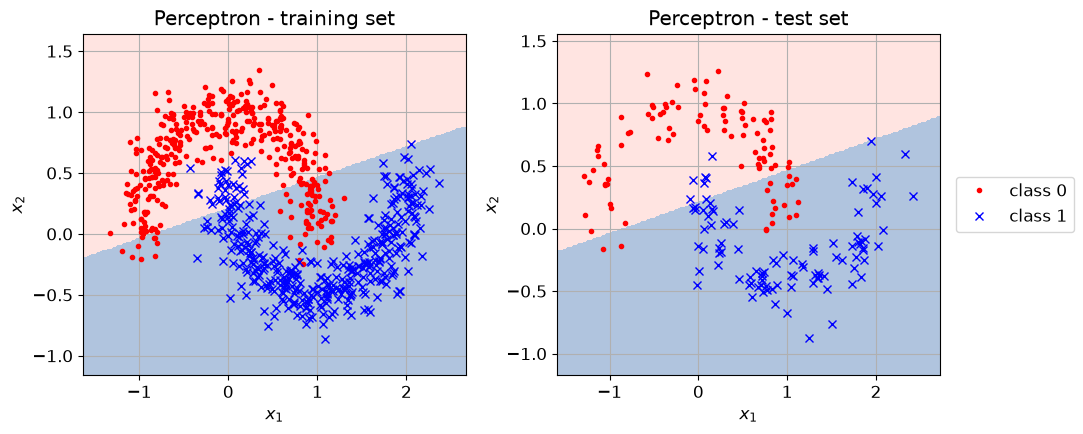

In [19]:
plot_train_test(per_clf.predict, "Perceptron")

### 9. Task 3: MLP with One Hidden Layer

In [20]:
tf.random.set_seed(42)

mlp1 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[2]),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

mlp1.compile(loss="binary_crossentropy",
             optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
             metrics=["accuracy"])
mlp1.fit(X_train, y_train, epochs=100, verbose=0)

print("train accuracy:", mlp1.evaluate(X_train, y_train, verbose=0)[1])
print("test accuracy: ", mlp1.evaluate(X_test, y_test, verbose=0)[1])

I0000 00:00:1786363054.295835  186697 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128176__.7


train accuracy: 0.9762499928474426


test accuracy:  0.9850000143051147


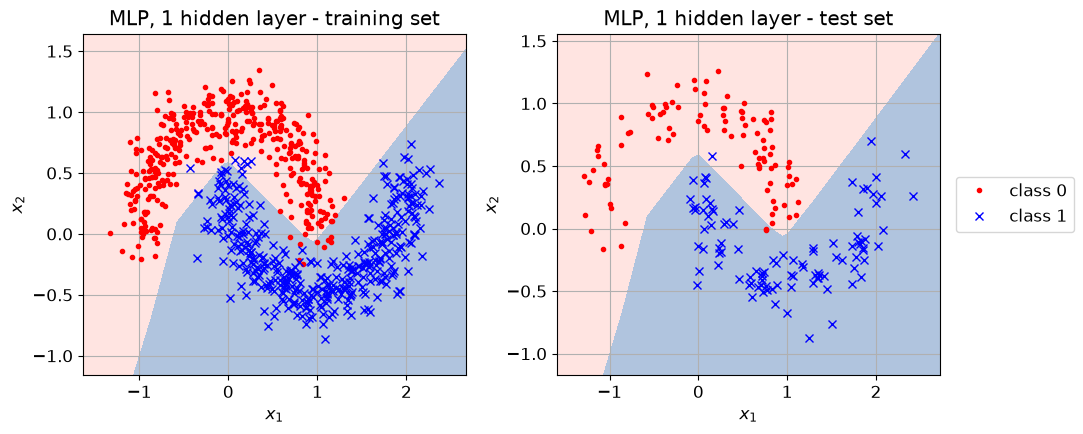

In [21]:
plot_train_test(keras_predict(mlp1), "MLP, 1 hidden layer")

### 10. Task 3: MLP with Two Hidden Layers

In [22]:
tf.random.set_seed(42)

mlp2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[2]),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

mlp2.compile(loss="binary_crossentropy",
             optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
             metrics=["accuracy"])
mlp2.fit(X_train, y_train, epochs=100, verbose=0)

print("train accuracy:", mlp2.evaluate(X_train, y_train, verbose=0)[1])
print("test accuracy: ", mlp2.evaluate(X_test, y_test, verbose=0)[1])

I0000 00:00:1786363064.436094  186696 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_158120__.8


train accuracy: 0.9925000071525574


test accuracy:  1.0


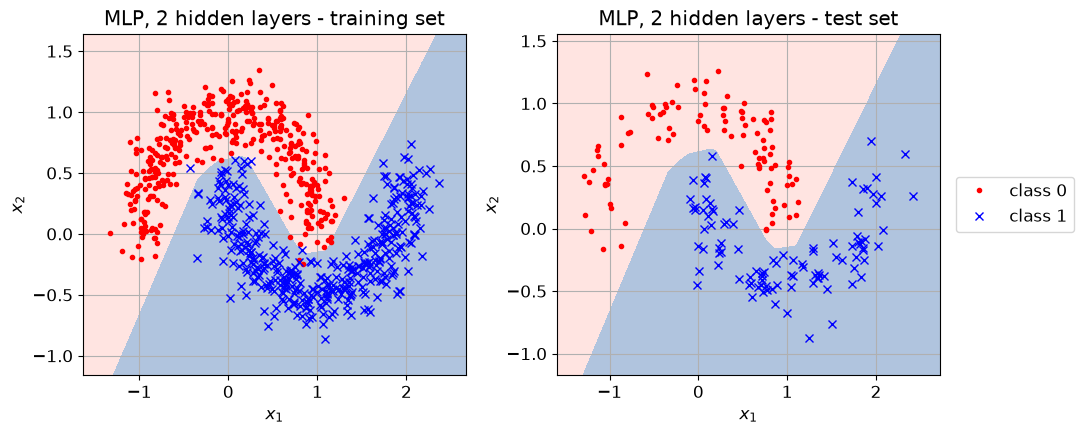

In [23]:
plot_train_test(keras_predict(mlp2), "MLP, 2 hidden layers")

### 11. Task 3: MLP without Activation Functions

In [24]:
tf.random.set_seed(42)

mlp3 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[2]),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

mlp3.compile(loss="binary_crossentropy",
             optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
             metrics=["accuracy"])
mlp3.fit(X_train, y_train, epochs=100, verbose=0)

print("train accuracy:", mlp3.evaluate(X_train, y_train, verbose=0)[1])
print("test accuracy: ", mlp3.evaluate(X_test, y_test, verbose=0)[1])

I0000 00:00:1786363074.140115  186694 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_188093__.8


train accuracy: 0.875


test accuracy:  0.8550000190734863


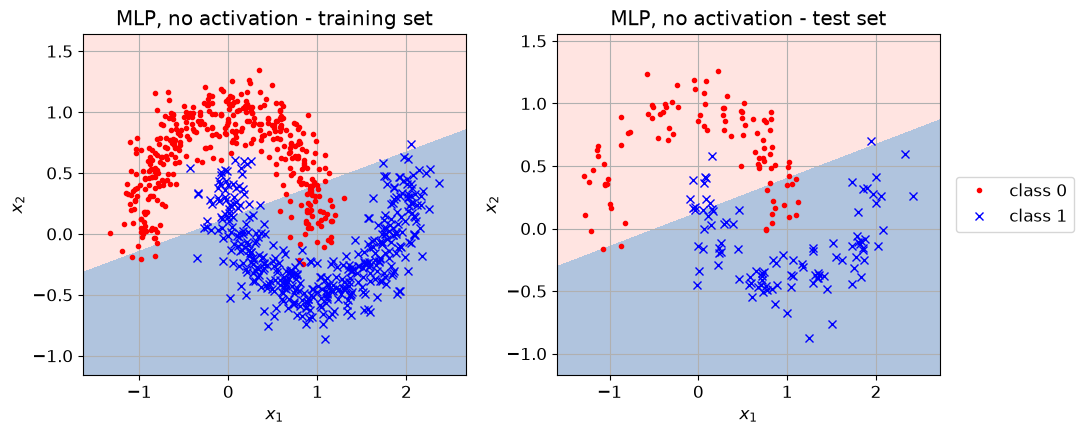

In [25]:
plot_train_test(keras_predict(mlp3), "MLP, no activation")

### 12. Task 3: Comparison

In [26]:
rows = [{
    "model": "Perceptron",
    "trainable params": per_clf.coef_.size + per_clf.intercept_.size,
    "train accuracy": per_clf.score(X_train, y_train),
    "test accuracy": per_clf.score(X_test, y_test),
}]

for name, model in [("MLP, 1 hidden layer", mlp1),
                    ("MLP, 2 hidden layers", mlp2),
                    ("MLP, no activation", mlp3)]:
    rows.append({
        "model": name,
        "trainable params": model.count_params(),
        "train accuracy": model.evaluate(X_train, y_train, verbose=0)[1],
        "test accuracy": model.evaluate(X_test, y_test, verbose=0)[1],
    })

pd.DataFrame(rows).set_index("model").round(4)

,trainable params,train accuracy,test accuracy
model,,,
Perceptron,3,0.8712,0.870
"MLP, 1 hidden layer",41,0.9762,0.985
"MLP, 2 hidden layers",91,0.9925,1.000
"MLP, no activation",91,0.8750,0.855


- The MLP with one hidden layer (98.5% test accuracy) clearly outperforms the Perceptron
  (87.0%). A Perceptron is a single linear classifier, and the two moons are not linearly
  separable, so its boundary is one straight line cutting through both crescents.
- Adding a second hidden layer improves things further, to 100% test accuracy, and the
  boundary follows the gap between the two moons much more closely.
- Removing the activation functions collapses the network back to a linear model. A stack
  of Dense layers with no non-linearity between them is still just one linear map, so
  despite having 91 trainable parameters it only scores 85.5%, the same range as the
  3-parameter Perceptron, and its decision boundary is a straight line again. The depth
  buys nothing without the activation functions.